> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 05 支持向量机（SVM）：最大间隔、核技巧与回归扩展

**本章目标**：理解 SVM 为什么寻找“最大间隔”边界，能从硬间隔推到软间隔与 Hinge Loss，
能解释支持向量、核技巧、`C` 与 `gamma`，并能手写线性 SVM、使用 sklearn 完成分类和回归。

> 数据均来自固定随机种子或 sklearn 内置数据，不需要下载外部文件。选择包含
> NumPy、Matplotlib、scikit-learn 的 Python 内核后，可以直接 **Run All**。

## 模型简介与学习参考

支持向量机（Support Vector Machine, SVM）是一类以**最大间隔**为核心的监督学习模型。
它先寻找离两类最近样本尽可能远的分类面，再通过软间隔处理噪声，通过核技巧处理非线性问题；
将分类间隔改造成 epsilon 不敏感管道后，还可得到支持向量回归（SVR）。

| 项目 | 内容 |
|---|---|
| **模型定位** | 基于间隔最大化的监督学习模型 |
| **核心思想** | 用少量支持向量确定具有较强泛化能力的决策边界或回归函数 |
| **适用任务** | 二分类、多分类和回归；本章重点讲二分类与 SVR |
| **主要优点** | 适合中小规模、高维数据；核函数可建立非线性模型；最优问题为凸优化 |
| **主要限制** | 对特征尺度和参数敏感；大样本核 SVM 训练较慢；决策分数不是原生概率 |

**学习参考**：

- 周志华：《机器学习》（西瓜书），第 6 章“支持向量机”；
- [Datawhale《南瓜书》：西瓜书公式详解](https://github.com/datawhalechina/pumpkin-book)；
- [scikit-learn：Support Vector Machines 用户指南](https://scikit-learn.org/stable/modules/svm.html)；
- [ML-From-Scratch：Support Vector Machine 实现](https://github.com/eriklindernoren/ML-From-Scratch/blob/master/mlfromscratch/supervised_learning/support_vector_machine.py)。

本章按照 **原理推导 → NumPy 手写 → sklearn 调用 → 真实案例 → 章节小结** 展开。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 分类起点：超平面与判别函数](#hyperplane)
  - [1.2 间隔定义：函数间隔与几何间隔](#margin)
  - [1.3 最大间隔：硬间隔 SVM 的优化目标](#hard-margin)
  - [1.4 容错间隔：软间隔与松弛变量](#soft-margin)
  - [1.5 损失转换：Hinge Loss 与正则化](#hinge-loss)
  - [1.6 关键样本：支持向量与决策边界](#support-vectors)
  - [1.7 非线性化：对偶问题与核技巧](#kernel)
  - [1.8 参数控制：`C`、`gamma` 与模型复杂度](#hyperparameters)
  - [1.9 回归扩展：epsilon 不敏感损失与 SVR](#svr-theory)
- [2. NumPy 手写线性 SVM](#scratch)
  - [2.1 图形复现：三张核心原理图](#figure-code)
  - [2.2 数据准备：模拟数据与评估工具](#scratch-data)
  - [2.3 模型实现：`LinearSVMSGD`](#scratch-model)
  - [2.4 训练评估：Loss、间隔与分类指标](#scratch-evaluation)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 分类调用：线性核与 RBF 核](#sklearn-basic)
  - [3.2 分类案例：乳腺癌恶性诊断](#real-classification)
  - [3.3 回归调用：SVR 与糖尿病进展预测](#regression-example)
    - [3.3.1 模型演示：epsilon 管道与支持向量](#svr-demo)
    - [3.3.2 回归案例：预测结果与残差评估](#svr-case)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

<a id="hyperplane"></a>
### 1.1 分类起点：超平面与判别函数

对二分类数据，令标签 $y_i\in\{-1,+1\}$，线性判别函数为

$$f(\mathbf{x})=\mathbf{w}^{\top}\mathbf{x}+b.$$

- $f(\mathbf{x})=0$ 是分类超平面；二维中是一条直线，三维中是一个平面；
- $\mathbf{w}$ 是超平面的法向量，决定方向；
- $b$ 控制超平面沿法向量平移；
- $f(\mathbf{x})>0$ 预测为 $+1$，$f(\mathbf{x})<0$ 预测为 $-1$。

只要所有训练点满足 $y_i f(\mathbf{x}_i)>0$，这个边界就能正确分类训练集。但通常存在很多条
能分开的直线。SVM 的核心问题不是“能不能分开”，而是：**哪一条边界离两类数据都更远？**
离最近样本仍然较远的边界，对小扰动更不敏感，这就是最大间隔思想。

<a id="margin"></a>
### 1.2 间隔定义：函数间隔与几何间隔

样本 $(\mathbf{x}_i,y_i)$ 的**函数间隔**为

$$\hat{\gamma}_i=y_i(\mathbf{w}^{\top}\mathbf{x}_i+b).$$

它的符号能判断分类是否正确，但数值不能直接表示真实距离：把 $(\mathbf{w},b)$ 同时乘以 10，
超平面完全不变，函数间隔却扩大 10 倍。因此必须除以法向量长度，得到到超平面的有符号距离：

$$\gamma_i=\frac{y_i(\mathbf{w}^{\top}\mathbf{x}_i+b)}{\|\mathbf{w}\|}.$$

这就是**几何间隔**。整个训练集的间隔由离边界最近的样本决定：

$$\gamma=\min_i\gamma_i.$$

为消除缩放自由度，约定最近样本的函数间隔等于 1，即
$y_i(\mathbf{w}^{\top}\mathbf{x}_i+b)\ge 1$。此时两条间隔边界是
$\mathbf{w}^{\top}\mathbf{x}+b=\pm1$，它们之间的距离为

$$\frac{1}{\|\mathbf{w}\|}+\frac{1}{\|\mathbf{w}\|}=\frac{2}{\|\mathbf{w}\|}.$$

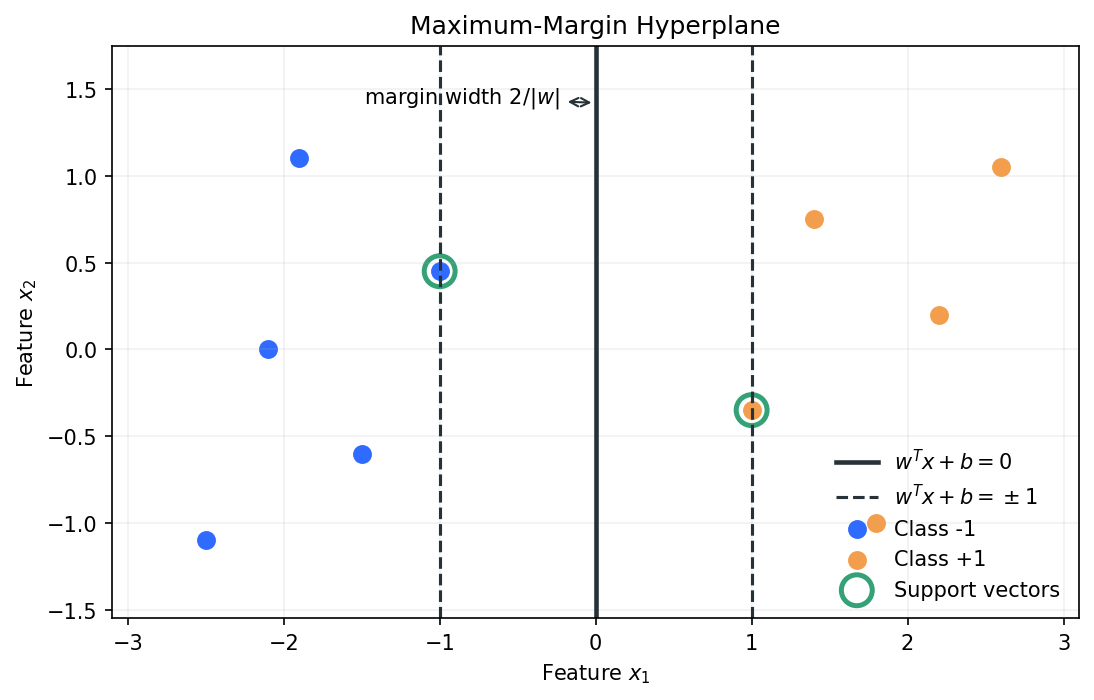

<a id="hard-margin"></a>
### 1.3 最大间隔：硬间隔 SVM 的优化目标

目标是最大化 $2/\|\mathbf{w}\|$。因为它随 $\|\mathbf{w}\|$ 单调减小，所以等价于最小化
$\|\mathbf{w}\|$；再平方并乘 $1/2$，只是为了求导方便，不改变最优解：

$$
\begin{aligned}
\min_{\mathbf{w},b}\quad &\frac12\|\mathbf{w}\|^2\\
\text{s.t.}\quad &y_i(\mathbf{w}^{\top}\mathbf{x}_i+b)\ge1,
\quad i=1,\ldots,m.
\end{aligned}
$$

这就是**硬间隔 SVM**。目标函数让间隔尽量宽，约束让每个点不仅分类正确，还要位于本类间隔线
外侧。它是凸二次规划，因此局部最优就是全局最优。

但硬间隔有一个明显前提：训练数据必须完全线性可分。一个异常点或标签噪声就可能让约束无解，
因而需要允许少量样本“没有站到理想位置”。

<a id="soft-margin"></a>
### 1.4 容错间隔：软间隔与松弛变量

为每个样本引入松弛变量 $\xi_i\ge0$：

$$y_i(\mathbf{w}^{\top}\mathbf{x}_i+b)\ge1-\xi_i.$$

$\xi_i$ 的含义可直接从有符号间隔读出：

| 条件 | 样本位置 | 含义 |
|---|---|---|
| $\xi_i=0$ | $y_if(\mathbf{x}_i)\ge1$ | 分类正确，且在间隔外或边界上 |
| $0<\xi_i<1$ | $0<y_if(\mathbf{x}_i)<1$ | 分类正确，但进入间隔带 |
| $\xi_i\ge1$ | $y_if(\mathbf{x}_i)\le0$ | 已到错误一侧或正好落在分类面上 |

同时追求大间隔和少违规，得到软间隔目标：

$$
\min_{\mathbf{w},b,\boldsymbol{\xi}}
\frac12\|\mathbf{w}\|^2+C\sum_{i=1}^{m}\xi_i,
\quad
\text{s.t. }y_i f(\mathbf{x}_i)\ge1-\xi_i,\ \xi_i\ge0.
$$

第一项控制模型复杂度，第二项惩罚间隔违规；$C$ 决定二者的权衡。

<a id="hinge-loss"></a>
### 1.5 损失转换：Hinge Loss 与正则化

对固定的 $(\mathbf{w},b)$，满足约束所需的最小松弛量是

$$\xi_i=\max\left(0,\ 1-y_if(\mathbf{x}_i)\right).$$

代回软间隔目标，得到常见的原始问题形式：

$$
J(\mathbf{w},b)=\frac12\|\mathbf{w}\|^2+
C\sum_{i=1}^{m}\max\left(0,1-y_i(\mathbf{w}^{\top}\mathbf{x}_i+b)\right).
$$

其中 $\max(0,1-yf)$ 就是 **Hinge Loss**：

- $yf\ge1$：不仅分类正确，而且在间隔外，损失为 0；
- $0<yf<1$：分类正确但间隔不足，仍受惩罚；
- $yf\le0$：分类错误，惩罚随错误程度线性增加。

Hinge Loss 在 $yf=1$ 处不可导，但存在次梯度，因此可使用次梯度下降。第 2 部分手写代码优化的是
平均损失版本，尺度略有不同，但“间隔正则化 + 违规惩罚”的含义完全相同。

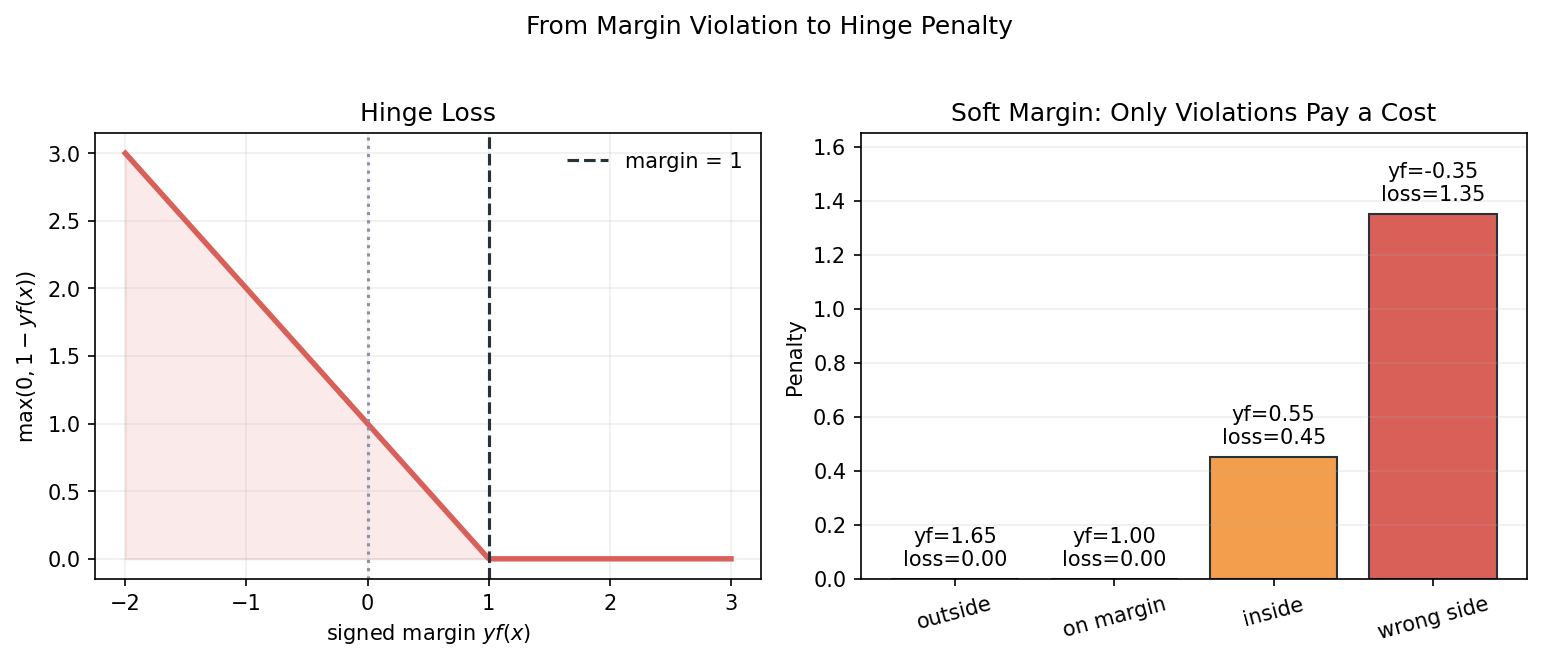

<a id="support-vectors"></a>
### 1.6 关键样本：支持向量与决策边界

在最优解附近，满足 $y_if(\mathbf{x}_i)\le1$ 的样本位于间隔边界上、间隔带内部，或被分错；
它们直接影响损失与边界，被称为**支持向量**。

距离边界很远且分类正确的样本满足 $y_if(\mathbf{x}_i)>1$，Hinge Loss 为 0。轻微移动这些远处样本，
最优超平面通常不变。真正“支撑”两条间隔线并决定分类面的，是靠近边界的少数样本。

这也是 SVM 与普通经验风险最小化的一个直观区别：它关注最困难、最靠近边界的数据，而不是让每个
已经分类正确的样本都继续远离边界。

<a id="kernel"></a>
### 1.7 非线性化：对偶问题与核技巧

对硬间隔约束引入拉格朗日乘子 $\alpha_i\ge0$，拉格朗日函数为

$$
L(\mathbf{w},b,\boldsymbol{\alpha})=
\frac12\|\mathbf{w}\|^2-
\sum_{i=1}^{m}\alpha_i\left[y_i(\mathbf{w}^{\top}\mathbf{x}_i+b)-1\right].
$$

对 $\mathbf{w}$ 和 $b$ 求驻点：

$$\mathbf{w}=\sum_i\alpha_i y_i\mathbf{x}_i,
\qquad \sum_i\alpha_i y_i=0.$$

代回后得到对偶问题：

$$
\max_{\boldsymbol{\alpha}}
\sum_i\alpha_i-rac12\sum_i\sum_j
\alpha_i\alpha_jy_iy_j\mathbf{x}_i^{\top}\mathbf{x}_j,
$$

软间隔时再增加 $0\le\alpha_i\le C$。关键观察是：样本只通过内积
$\mathbf{x}_i^{\top}\mathbf{x}_j$ 出现。如果先做非线性映射 $\phi(\mathbf{x})$，只需计算

$$K(\mathbf{x}_i,\mathbf{x}_j)=
\phi(\mathbf{x}_i)^{\top}\phi(\mathbf{x}_j),$$

不必显式构造可能很高维的 $\phi(\mathbf{x})$，这就是**核技巧**。预测函数成为

$$f(\mathbf{x})=\sum_{i\in SV}\alpha_i y_iK(\mathbf{x}_i,\mathbf{x})+b.$$

常见核函数：线性核 $K=\mathbf{x}^{\top}\mathbf{z}$；多项式核
$K=(\gamma\mathbf{x}^{\top}\mathbf{z}+r)^d$；RBF 核
$K=\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$。

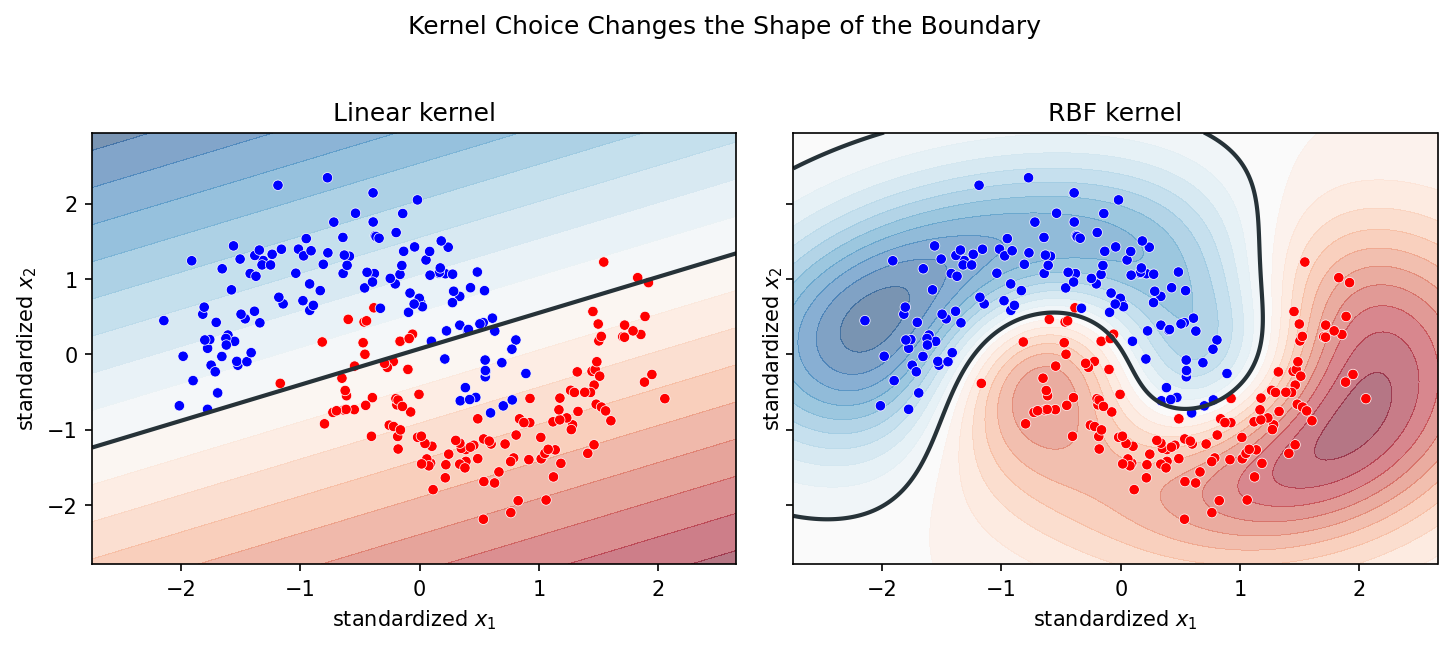

<a id="hyperparameters"></a>
### 1.8 参数控制：`C`、`gamma` 与模型复杂度

| 参数 | 较小 | 较大 |
|---|---|---|
| `C` | 更容忍间隔违规，边界更平滑，可能欠拟合 | 更强调训练样本分类正确，边界更贴数据，可能过拟合 |
| RBF 的 `gamma` | 单个样本影响范围大，边界较平滑 | 单个样本影响范围小，边界更曲折，可能过拟合 |

二者不能孤立理解：大 `C` 与大 `gamma` 的组合尤其容易追逐噪声。SVM 还依赖距离与内积，因此不同量纲
会改变几何关系；实际使用中通常先标准化特征，再用交叉验证选择 `C` 和 `gamma`。

另外，SVM 的 `decision_function` 输出的是到判别边界相关的**决策分数**，不是概率。ROC 与 AUC 只需要
排序分数，因此无需为了画 ROC 强制开启 `probability=True`。

<a id="svr-theory"></a>
### 1.9 回归扩展：epsilon 不敏感损失与 SVR

支持向量回归（SVR）不再寻找分隔两类的间隔，而是在回归函数周围建立宽度为 $2\varepsilon$ 的管道。
预测误差落在管道内时不计损失，超过管道才受到惩罚：

$$
L_{\varepsilon}(y,f(\mathbf{x}))=
\max\left(0,\ |y-f(\mathbf{x})|-\varepsilon\right).
$$

相应目标可写为

$$
\min_{\mathbf{w},b}
\frac12\|\mathbf{w}\|^2+C\sum_i
\max\left(0,|y_i-f(\mathbf{x}_i)|-\varepsilon\right).
$$

因此：`epsilon` 控制“多大的误差可以忽略”，`C` 控制超出管道后的惩罚，核函数仍可产生非线性回归。
位于管道外或边界上的样本成为支持向量。第 3.3 节用 `SVR` 给出完整回归示例。

<a id="scratch"></a>
## 2. NumPy 手写线性 SVM

<a id="figure-code"></a>
### 2.1 图形复现：三张核心原理图

上面的图已经作为附件嵌入；以下代码用于复现这些图，同时完成本章统一导入。手写模型本身只使用
NumPy，不调用 sklearn 的 SVM 实现。

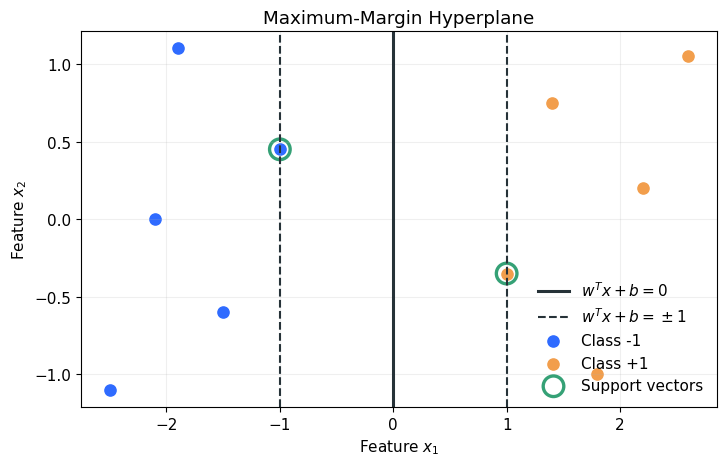

In [1]:
# 复现图 1：最大间隔与支持向量
import json
import numpy as np
import matplotlib.pyplot as plt

BLUE = "#2F6BFF"
ORANGE = "#F29E4C"
DARK = "#263238"
GREY = "#8A94A6"
GREEN = "#35A176"
RED = "#D95F59"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.20, "font.size": 11})

negative_points = np.array([
    [-2.5, -1.1], [-2.1, 0.0], [-1.9, 1.1], [-1.5, -0.6], [-1.0, 0.45]
])
positive_points = np.array([
    [1.0, -0.35], [1.4, 0.75], [1.8, -1.0], [2.2, 0.2], [2.6, 1.05]
])

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.scatter(negative_points[:, 0], negative_points[:, 1], color=BLUE, s=65, label="Class -1")
ax.scatter(positive_points[:, 0], positive_points[:, 1], color=ORANGE, s=65, label="Class +1")
ax.axvline(0, color=DARK, linewidth=2.2, label=r"$w^Tx+b=0$")
ax.axvline(-1, color=DARK, linestyle="--", linewidth=1.5, label=r"$w^Tx+b=\pm1$")
ax.axvline(1, color=DARK, linestyle="--", linewidth=1.5)
ax.scatter([-1, 1], [0.45, -0.35], s=220, facecolors="none", edgecolors=GREEN,
           linewidths=2.4, label="Support vectors")
ax.set(xlabel=r"Feature $x_1$", ylabel=r"Feature $x_2$",
       title="Maximum-Margin Hyperplane")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

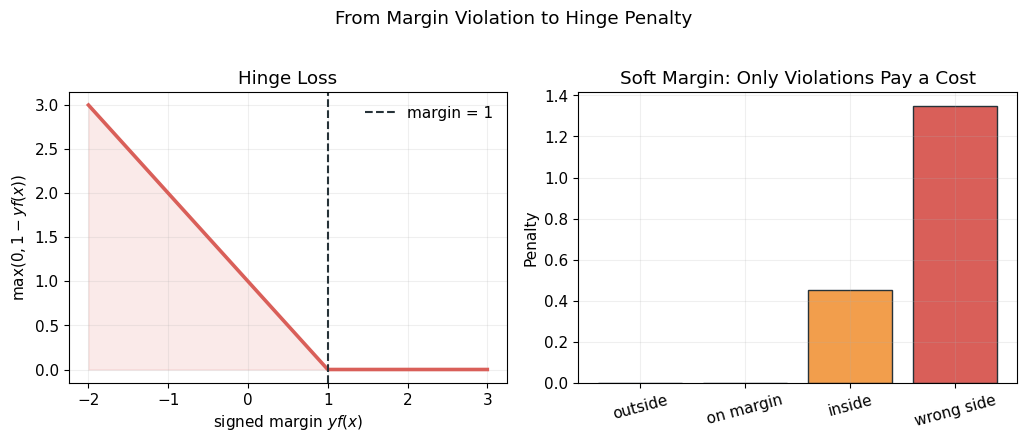

In [2]:
# 复现图 2：Hinge Loss 与软间隔
signed_margin = np.linspace(-2.0, 3.0, 400)
hinge_loss = np.maximum(0.0, 1.0 - signed_margin)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3))
axes[0].plot(signed_margin, hinge_loss, color=RED, linewidth=2.6)
axes[0].axvline(1, color=DARK, linestyle="--", label="margin = 1")
axes[0].fill_between(signed_margin, hinge_loss, where=signed_margin < 1,
                     color=RED, alpha=0.13)
axes[0].set(xlabel=r"signed margin $y f(x)$", ylabel=r"$\max(0,1-yf(x))$",
            title="Hinge Loss")
axes[0].legend(frameon=False)

example_margins = np.array([1.65, 1.0, 0.55, -0.35])
example_losses = np.maximum(0.0, 1.0 - example_margins)
labels = ["outside", "on margin", "inside", "wrong side"]
axes[1].bar(labels, example_losses, color=[GREEN, BLUE, ORANGE, RED], edgecolor=DARK)
axes[1].set(ylabel="Penalty", title="Soft Margin: Only Violations Pay a Cost")
axes[1].tick_params(axis="x", rotation=15)
fig.suptitle("From Margin Violation to Hinge Penalty", y=1.02)
plt.tight_layout()
plt.show()

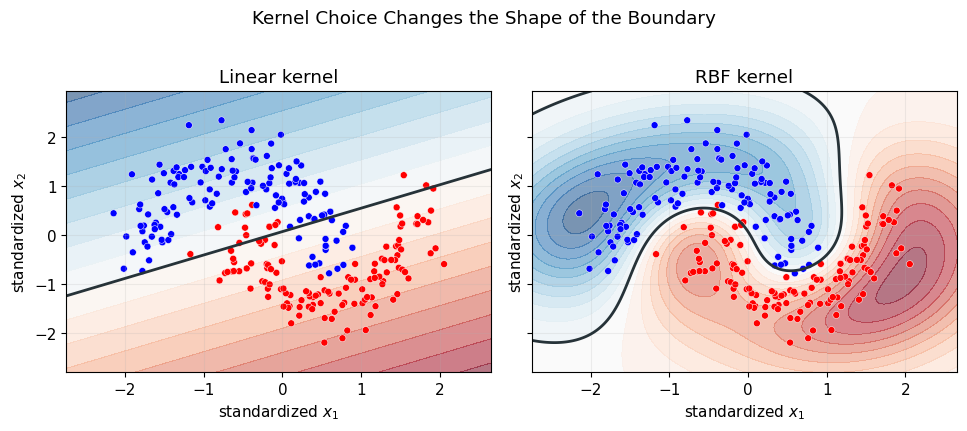

In [3]:
# 复现图 3：线性核与 RBF 核
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

kernel_X, kernel_y = make_moons(n_samples=260, noise=0.18, random_state=42)
kernel_X_scaled = StandardScaler().fit_transform(kernel_X)
kernel_models = [
    ("Linear kernel", SVC(kernel="linear", C=1.0)),
    ("RBF kernel", SVC(kernel="rbf", C=3.0, gamma="scale")),
]
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(kernel_X_scaled[:, 0].min() - 0.6, kernel_X_scaled[:, 0].max() + 0.6, 260),
    np.linspace(kernel_X_scaled[:, 1].min() - 0.6, kernel_X_scaled[:, 1].max() + 0.6, 260),
)
kernel_grid = np.c_[grid_x1.ravel(), grid_x2.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.2), sharex=True, sharey=True)
for ax, (title, model) in zip(axes, kernel_models):
    model.fit(kernel_X_scaled, kernel_y)
    grid_score = model.decision_function(kernel_grid).reshape(grid_x1.shape)
    ax.contourf(grid_x1, grid_x2, grid_score, levels=20, cmap="RdBu_r", alpha=0.55)
    ax.contour(grid_x1, grid_x2, grid_score, levels=[0], colors=DARK, linewidths=2)
    ax.scatter(kernel_X_scaled[:, 0], kernel_X_scaled[:, 1], c=kernel_y,
               cmap="bwr", s=25, edgecolor="white", linewidth=0.35)
    ax.set(title=title, xlabel=r"standardized $x_1$", ylabel=r"standardized $x_2$")
fig.suptitle("Kernel Choice Changes the Shape of the Boundary", y=1.02)
plt.tight_layout()
plt.show()

<a id="scratch-data"></a>
### 2.2 数据准备：模拟数据与评估工具

使用二维近似线性可分数据观察最大间隔。数据划分和指标计算调用 sklearn；模型参数学习、决策分数
和预测全部由后面的 NumPy 类完成。标准化很重要，因为 SVM 的间隔依赖特征空间中的距离。

In [4]:
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

manual_X, manual_y = make_blobs(
    n_samples=420,
    centers=[(-1.8, -1.35), (1.55, 1.40)],
    cluster_std=[0.95, 1.00],
    random_state=42,
)
manual_X_train, manual_X_test, manual_y_train, manual_y_test = train_test_split(
    manual_X, manual_y, test_size=0.25, stratify=manual_y, random_state=42
)
manual_scaler = StandardScaler()
manual_X_train_scaled = manual_scaler.fit_transform(manual_X_train)
manual_X_test_scaled = manual_scaler.transform(manual_X_test)

def evaluate_binary(y_true, y_prediction, decision_score):
    return {
        "Accuracy": accuracy_score(y_true, y_prediction),
        "Precision": precision_score(y_true, y_prediction),
        "Recall": recall_score(y_true, y_prediction),
        "F1": f1_score(y_true, y_prediction),
        "ROC-AUC": roc_auc_score(y_true, decision_score),
    }

def print_metrics(title, metrics):
    print(title)
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name:9s}: {metric_value:.4f}")

def plot_binary_evaluation(y_true, y_prediction, decision_score, title, class_names):
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, decision_score)
    auc_value = roc_auc_score(y_true, decision_score)
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_prediction, display_labels=class_names,
        cmap="Blues", colorbar=False, ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].grid(False)
    axes[1].plot(false_positive_rate, true_positive_rate, color=BLUE,
                 linewidth=2.2, label=f"ROC-AUC = {auc_value:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color=GREY, label="Random classifier")
    axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
                title="ROC Curve")
    axes[1].legend(loc="lower right", frameon=False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

<a id="scratch-model"></a>
### 2.3 模型实现：`LinearSVMSGD`

这里优化平均 Hinge Loss 形式：

$$J=\frac12\|\mathbf{w}\|^2+C\frac1m\sum_i\max(0,1-y_if_i).$$

对一个小批量 $B$，令 $V=\{i\in B:y_if_i<1\}$，其次梯度为

$$
\frac{\partial J}{\partial\mathbf{w}}=
\mathbf{w}-\frac{C}{|B|}\sum_{i\in V}y_i\mathbf{x}_i,
\qquad
\frac{\partial J}{\partial b}=-\frac{C}{|B|}\sum_{i\in V}y_i.
$$

因为这里对 Hinge Loss 取均值，`C` 的数值尺度不能与使用损失总和的公式或 sklearn 直接比较；本例取
`C=100`，让少量边界样本承担主要惩罚。偏置 $b$ 不决定间隔宽度，所以不对 $b$ 做 L2 正则化。
学习率随 epoch 缓慢衰减，以减少后期振荡。

In [5]:
class LinearSVMSGD:
    def __init__(self, learning_rate=0.035, C=100.0, epochs=700,
                 batch_size=64, random_state=42):
        self.learning_rate = learning_rate
        self.C = C
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        y_signed = np.where(y == 1, 1.0, -1.0)
        self.w_ = np.zeros(X.shape[1], dtype=float)
        self.b_ = 0.0
        self.loss_history_ = []
        random_generator = np.random.default_rng(self.random_state)

        for epoch in range(self.epochs):
            learning_rate = self.learning_rate / (1.0 + 0.006 * epoch)
            shuffled_indices = random_generator.permutation(len(X))

            for start in range(0, len(X), self.batch_size):
                batch_indices = shuffled_indices[start:start + self.batch_size]
                batch_X = X[batch_indices]
                batch_y = y_signed[batch_indices]
                margins = batch_y * (batch_X @ self.w_ + self.b_)
                active = margins < 1.0

                gradient_w = self.w_.copy()
                gradient_b = 0.0
                if np.any(active):
                    gradient_w -= self.C * np.sum(
                        batch_y[active, None] * batch_X[active], axis=0
                    ) / len(batch_X)
                    gradient_b = -self.C * np.sum(batch_y[active]) / len(batch_X)

                self.w_ -= learning_rate * gradient_w
                self.b_ -= learning_rate * gradient_b

            full_margin = y_signed * (X @ self.w_ + self.b_)
            objective = (
                0.5 * np.dot(self.w_, self.w_)
                + self.C * np.mean(np.maximum(0.0, 1.0 - full_margin))
            )
            self.loss_history_.append(float(objective))

        self.support_mask_ = y_signed * self.decision_function(X) <= 1.05
        return self

    def decision_function(self, X):
        return np.asarray(X, dtype=float) @ self.w_ + self.b_

    def predict(self, X):
        return (self.decision_function(X) >= 0.0).astype(int)

<a id="scratch-evaluation"></a>
### 2.4 训练评估：Loss、间隔与分类指标

Loss 用来检查优化过程；Accuracy、Precision、Recall、F1 用来检查固定阈值下的分类；ROC-AUC 使用
`decision_function` 分数检查所有阈值下的排序能力。三者回答的问题不同，因此都保留。

In [6]:
manual_model = LinearSVMSGD().fit(manual_X_train_scaled, manual_y_train)
manual_score = manual_model.decision_function(manual_X_test_scaled)
manual_prediction = manual_model.predict(manual_X_test_scaled)
manual_metrics = evaluate_binary(manual_y_test, manual_prediction, manual_score)

print("手写模型验证通过")
print("w =", np.round(manual_model.w_, 4), "; b =", round(manual_model.b_, 4))
print("Support vectors (training approximation):", int(manual_model.support_mask_.sum()))
print_metrics("Handwritten linear SVM metrics", manual_metrics)

手写模型验证通过
w = [1.8797 1.007 ] ; b = 0.0585
Support vectors (training approximation): 26
Handwritten linear SVM metrics
Accuracy : 0.9905
Precision: 1.0000
Recall   : 0.9808
F1       : 0.9903
ROC-AUC  : 1.0000


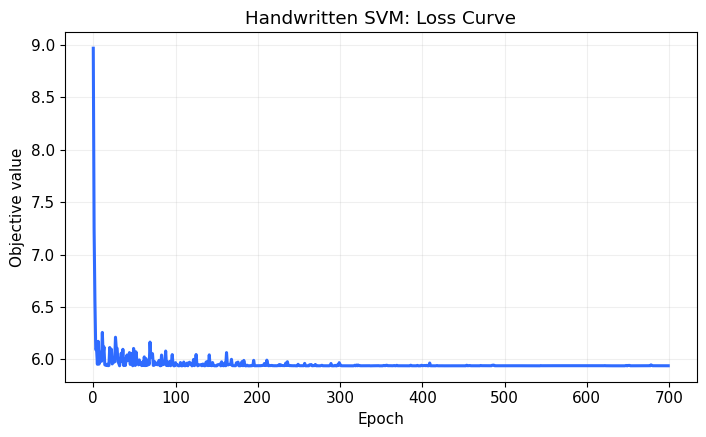

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.plot(manual_model.loss_history_, color=BLUE, linewidth=2.2)
ax.set(xlabel="Epoch", ylabel="Objective value", title="Handwritten SVM: Loss Curve")
plt.tight_layout()
plt.show()

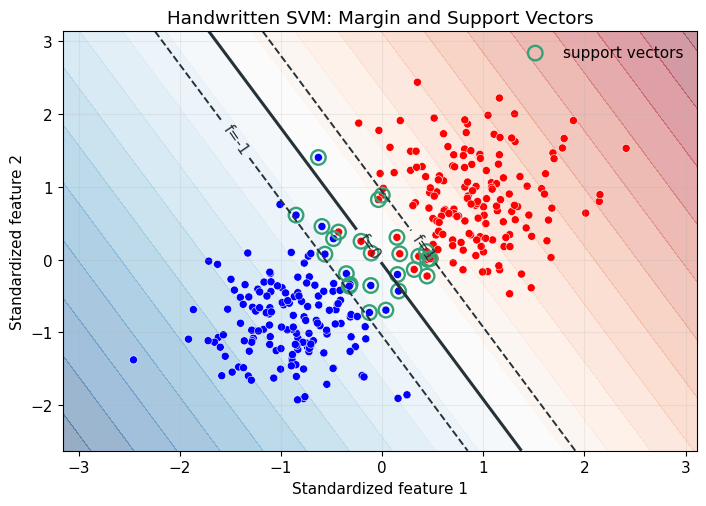

In [8]:
margin = 0.7
plot_x1, plot_x2 = np.meshgrid(
    np.linspace(manual_X_train_scaled[:, 0].min() - margin,
                manual_X_train_scaled[:, 0].max() + margin, 300),
    np.linspace(manual_X_train_scaled[:, 1].min() - margin,
                manual_X_train_scaled[:, 1].max() + margin, 300),
)
plot_grid = np.c_[plot_x1.ravel(), plot_x2.ravel()]
plot_score = manual_model.decision_function(plot_grid).reshape(plot_x1.shape)
support_X = manual_X_train_scaled[manual_model.support_mask_]

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.contourf(plot_x1, plot_x2, plot_score, levels=25, cmap="RdBu_r", alpha=0.42)
contours = ax.contour(plot_x1, plot_x2, plot_score, levels=[-1, 0, 1],
                      colors=[DARK, DARK, DARK], linestyles=["--", "-", "--"],
                      linewidths=[1.4, 2.2, 1.4])
ax.clabel(contours, fmt={-1: "f=-1", 0: "f=0", 1: "f=1"})
ax.scatter(manual_X_train_scaled[:, 0], manual_X_train_scaled[:, 1], c=manual_y_train,
           cmap="bwr", s=34, edgecolor="white", linewidth=0.4)
ax.scatter(support_X[:, 0], support_X[:, 1], s=110, facecolors="none",
           edgecolors=GREEN, linewidths=1.7, label="support vectors")
ax.set(xlabel="Standardized feature 1", ylabel="Standardized feature 2",
       title="Handwritten SVM: Margin and Support Vectors")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

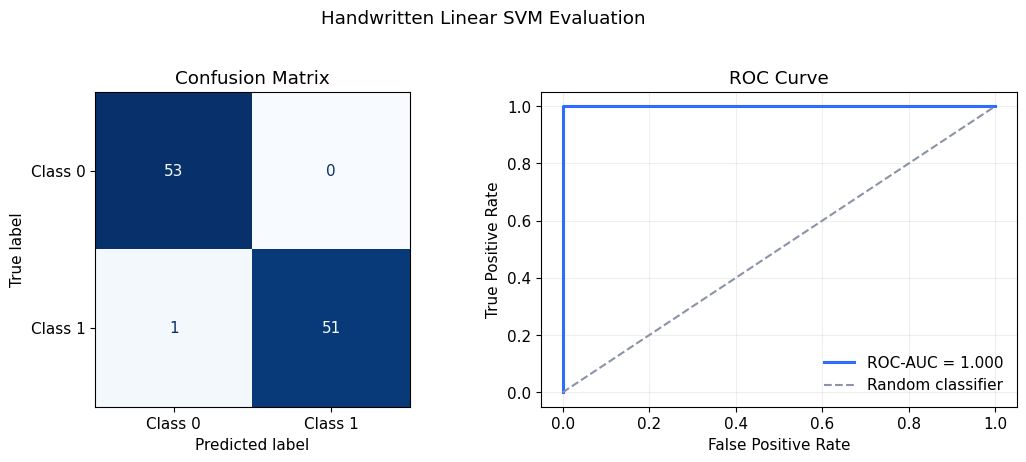

In [9]:
plot_binary_evaluation(
    manual_y_test,
    manual_prediction,
    manual_score,
    "Handwritten Linear SVM Evaluation",
    ["Class 0", "Class 1"],
)

Loss 从较高值下降并趋于稳定，说明次梯度更新确实在降低目标；圈出的点满足训练间隔不大于约 1，
因而对边界最关键。边界图解释模型“如何分”，混淆矩阵解释“错在哪里”，ROC 则评价分数排序能力。

<a id="sklearn"></a>
## 3. sklearn 调用与案例

本部分不再重复公式，统一采用：**导入 → 数据划分 → 标准化 → 拟合 → 预测 → 指标 → 图形 → 结论**。

<a id="sklearn-basic"></a>
### 3.1 分类调用：线性核与 RBF 核

月牙数据不是线性可分的，适合观察核函数的作用。先训练两个完整 Pipeline，再比较边界；随后对 RBF
模型给出与前面一致的分类指标、混淆矩阵和 ROC。

In [10]:
# 1) 导入 sklearn 组件
from sklearn.pipeline import make_pipeline

# 2) 数据与划分
basic_X, basic_y = make_moons(n_samples=480, noise=0.18, random_state=42)
basic_X_train, basic_X_test, basic_y_train, basic_y_test = train_test_split(
    basic_X, basic_y, test_size=0.25, stratify=basic_y, random_state=42
)

# 3) 标准化 + 拟合
basic_linear_model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0))
basic_rbf_model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=3.0, gamma="scale"))
basic_linear_model.fit(basic_X_train, basic_y_train)
basic_rbf_model.fit(basic_X_train, basic_y_train)

# 4) 预测与指标（ROC 直接使用决策分数）
basic_score = basic_rbf_model.decision_function(basic_X_test)
basic_prediction = basic_rbf_model.predict(basic_X_test)
basic_metrics = evaluate_binary(basic_y_test, basic_prediction, basic_score)

print_metrics("基础调用：RBF SVC", basic_metrics)

基础调用：RBF SVC
Accuracy : 0.9583
Precision: 0.9508
Recall   : 0.9667
F1       : 0.9587
ROC-AUC  : 0.9953


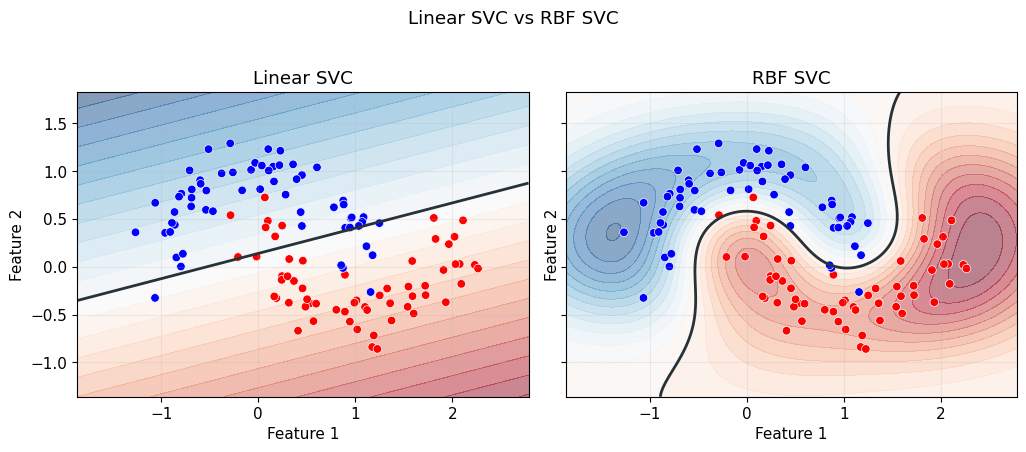

In [11]:
boundary_x1, boundary_x2 = np.meshgrid(
    np.linspace(basic_X[:, 0].min() - 0.5, basic_X[:, 0].max() + 0.5, 300),
    np.linspace(basic_X[:, 1].min() - 0.5, basic_X[:, 1].max() + 0.5, 300),
)
boundary_grid = np.c_[boundary_x1.ravel(), boundary_x2.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4), sharex=True, sharey=True)
for ax, (name, model) in zip(
    axes,
    [("Linear SVC", basic_linear_model), ("RBF SVC", basic_rbf_model)],
):
    boundary_score = model.decision_function(boundary_grid).reshape(boundary_x1.shape)
    ax.contourf(boundary_x1, boundary_x2, boundary_score, levels=25,
                cmap="RdBu_r", alpha=0.50)
    ax.contour(boundary_x1, boundary_x2, boundary_score, levels=[0],
               colors=DARK, linewidths=2)
    ax.scatter(basic_X_test[:, 0], basic_X_test[:, 1], c=basic_y_test,
               cmap="bwr", s=38, edgecolor="white", linewidth=0.5)
    ax.set(title=name, xlabel="Feature 1", ylabel="Feature 2")
fig.suptitle("Linear SVC vs RBF SVC", y=1.02)
plt.tight_layout()
plt.show()

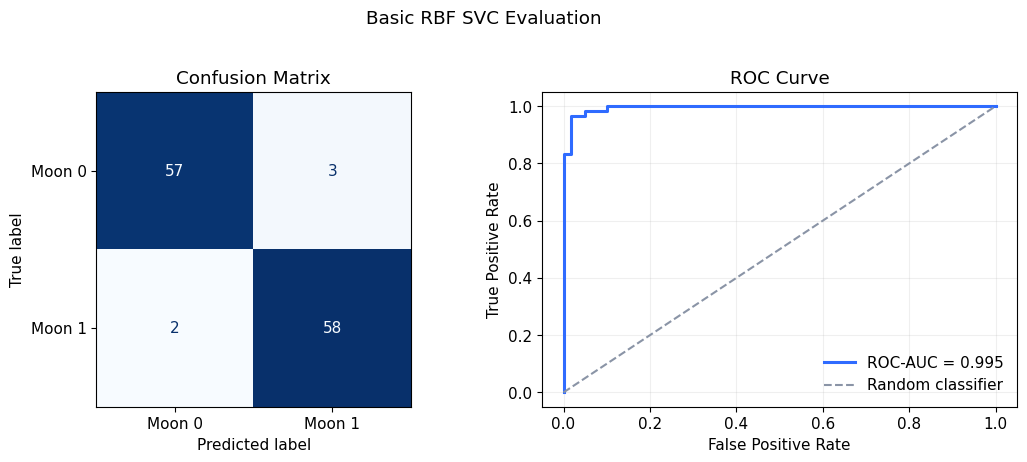

In [12]:
plot_binary_evaluation(
    basic_y_test,
    basic_prediction,
    basic_score,
    "Basic RBF SVC Evaluation",
    ["Moon 0", "Moon 1"],
)

线性核只能形成直线，难以贴合两条月牙；RBF 核根据样本间的局部相似度形成弯曲边界。这里的提升来自
数据结构与模型假设更匹配，并不代表 RBF 在所有任务中都优于线性核。

<a id="real-classification"></a>
### 3.2 分类案例：乳腺癌恶性诊断

`load_breast_cancer` 含 569 个样本、30 个由细胞核图像提取的连续特征。原始标签 0 为 malignant、
1 为 benign；这里重新编码，让“恶性”成为正类 1，因此 Recall 表示检出恶性肿瘤的比例。

这是高维数据，不能直接画真实二维决策边界，所以保留完整指标、混淆矩阵和 ROC。示例用于演示建模
流程，不可替代临床验证。

In [13]:
# 1) 导入与数据
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
real_X = cancer.data
real_y = (cancer.target == 0).astype(int)  # 1 = malignant

# 2) 划分
real_X_train, real_X_test, real_y_train, real_y_test = train_test_split(
    real_X, real_y, test_size=0.20, stratify=real_y, random_state=42
)

# 3) 标准化、拟合与预测
real_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced"),
)
real_model.fit(real_X_train, real_y_train)
real_score = real_model.decision_function(real_X_test)
real_prediction = real_model.predict(real_X_test)
real_metrics = evaluate_binary(real_y_test, real_prediction, real_score)

print(f"真实分类案例：乳腺癌恶性诊断（samples={real_X.shape[0]}, features={real_X.shape[1]}）")
print_metrics("RBF SVC metrics", real_metrics)

真实分类案例：乳腺癌恶性诊断（samples=569, features=30）
RBF SVC metrics
Accuracy : 0.9825
Precision: 1.0000
Recall   : 0.9524
F1       : 0.9756
ROC-AUC  : 0.9950


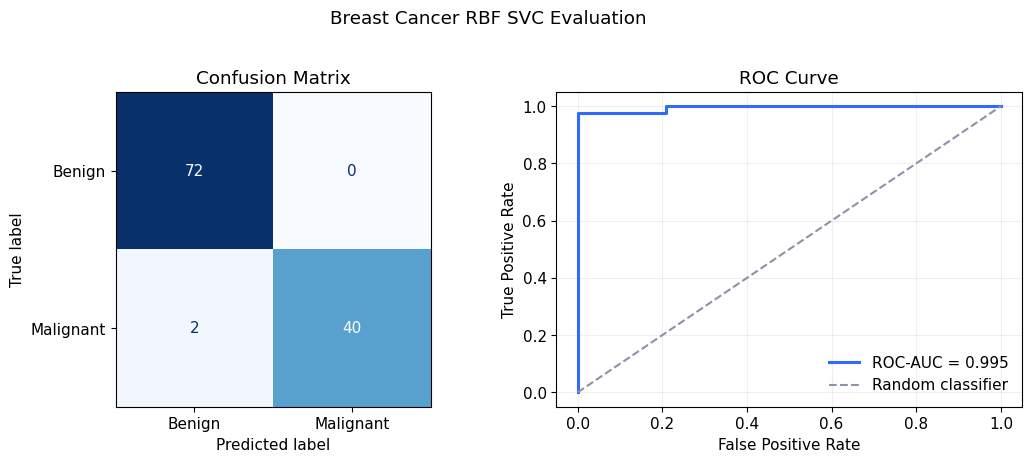

In [14]:
plot_binary_evaluation(
    real_y_test,
    real_prediction,
    real_score,
    "Breast Cancer RBF SVC Evaluation",
    ["Benign", "Malignant"],
)

在这个案例中，Recall 尤其值得关注，因为漏检恶性样本（FN）的代价通常高于一次进一步检查。
ROC-AUC 评价整体排序能力，实际部署仍需结合误诊与漏诊成本选择阈值，并在独立临床数据上验证。

<a id="regression-example"></a>
### 3.3 回归调用：SVR 与糖尿病进展预测

回归没有 Accuracy 和 ROC。与分类的“决策边界 + 指标 + ROC”对应，本节保留三类核心结果：

1. **拟合效果**：低维数据画回归曲线；高维数据画真实值 vs 预测值；
2. **回归指标**：MAE、RMSE、$R^2$；
3. **误差诊断**：残差图。

<a id="svr-demo"></a>
#### 3.3.1 模型演示：epsilon 管道与支持向量

先用一维数据把 SVR 的输出画出来。蓝线是预测函数，浅蓝区域是 $\pm\varepsilon$ 管道；橙色空心点是
sklearn 返回的支持向量。管道只表示训练损失中的“不敏感区”，不是统计意义上的预测置信区间。

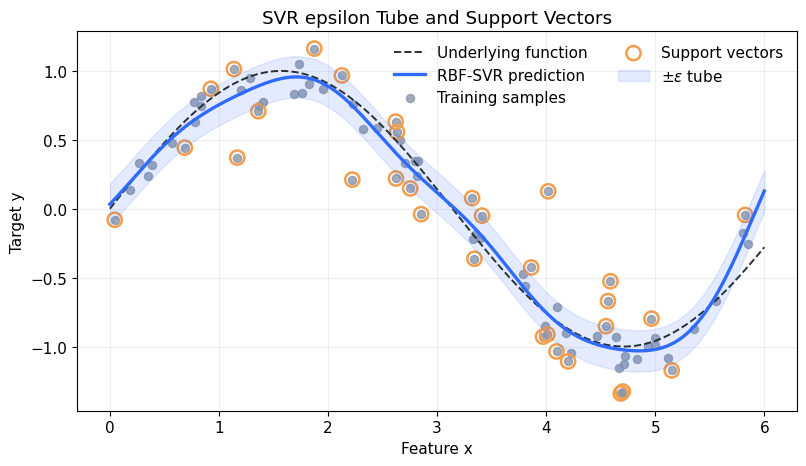

In [15]:
# 1) 导入 sklearn 回归组件并准备表格显示函数
from IPython.display import HTML, display
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR

def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    table_html = (
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    )
    display(HTML(table_html))

random_generator = np.random.default_rng(42)
svr_demo_X = np.sort(random_generator.uniform(0.0, 6.0, 80))[:, None]
svr_demo_true = np.sin(svr_demo_X[:, 0])
svr_demo_y = svr_demo_true + random_generator.normal(0.0, 0.16, len(svr_demo_X))
svr_demo_y[::13] += random_generator.normal(0.0, 0.45, len(svr_demo_y[::13]))

svr_demo_model = SVR(kernel="rbf", C=20.0, gamma=0.7, epsilon=0.15)
svr_demo_model.fit(svr_demo_X, svr_demo_y)
svr_demo_grid = np.linspace(0.0, 6.0, 500)[:, None]
svr_demo_prediction = svr_demo_model.predict(svr_demo_grid)
svr_demo_support = svr_demo_model.support_

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.scatter(svr_demo_X[:, 0], svr_demo_y, color=GREY, s=34, alpha=0.78,
           label="Training samples")
ax.scatter(svr_demo_X[svr_demo_support, 0], svr_demo_y[svr_demo_support],
           s=105, facecolors="none", edgecolors=ORANGE, linewidths=1.8,
           label="Support vectors")
ax.plot(svr_demo_grid[:, 0], np.sin(svr_demo_grid[:, 0]), "--",
        color=DARK, linewidth=1.4, label="Underlying function")
ax.plot(svr_demo_grid[:, 0], svr_demo_prediction, color=BLUE,
        linewidth=2.4, label="RBF-SVR prediction")
ax.fill_between(
    svr_demo_grid[:, 0],
    svr_demo_prediction - svr_demo_model.epsilon,
    svr_demo_prediction + svr_demo_model.epsilon,
    color=BLUE, alpha=0.13, label=r"$\pm\varepsilon$ tube",
)
ax.set(xlabel="Feature x", ylabel="Target y",
       title="SVR epsilon Tube and Support Vectors")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

管道内样本的误差不进入 epsilon 不敏感损失；落在管道边界或外侧的样本决定回归函数，因此成为支持向量。
这张图相当于分类任务中的“决策边界图”，用于理解模型拟合出了什么。

<a id="svr-case"></a>
#### 3.3.2 回归案例：预测结果与残差评估

`load_diabetes` 含 442 个样本和 10 个生理特征，目标是基线后一年疾病进展的定量指标。高维数据无法
直接画一条真实回归曲线，因此使用 Pipeline 完成标准化和 RBF-SVR，并用真实值—预测值及残差检查结果。

In [16]:
# 2) 数据与划分
diabetes = load_diabetes()
regression_X_train, regression_X_test, regression_y_train, regression_y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.20, random_state=42
)

# 3) 标准化、拟合与预测
regression_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=100.0, epsilon=10.0, gamma="scale"),
)
regression_model.fit(regression_X_train, regression_y_train)
regression_prediction = regression_model.predict(regression_X_test)

svr_mae = mean_absolute_error(regression_y_test, regression_prediction)
svr_rmse = mean_squared_error(regression_y_test, regression_prediction, squared=False)
svr_r2 = r2_score(regression_y_test, regression_prediction)

print("回归示例：糖尿病进展预测")
display_result_table(
    "糖尿病 SVR 指标表（Diabetes SVR metrics）",
    ["指标", "数值", "含义"],
    [
        ["MAE", f"{svr_mae:.3f}", "平均绝对预测误差"],
        ["RMSE", f"{svr_rmse:.3f}", "对较大的预测误差更敏感"],
        ["R²", f"{svr_r2:.3f}", "相对恒预测均值基线所解释的变异"],
    ],
)

回归示例：糖尿病进展预测


指标,数值,含义
MAE,40.010,平均绝对预测误差
RMSE,51.462,对较大的预测误差更敏感
R²,0.500,相对恒预测均值基线所解释的变异


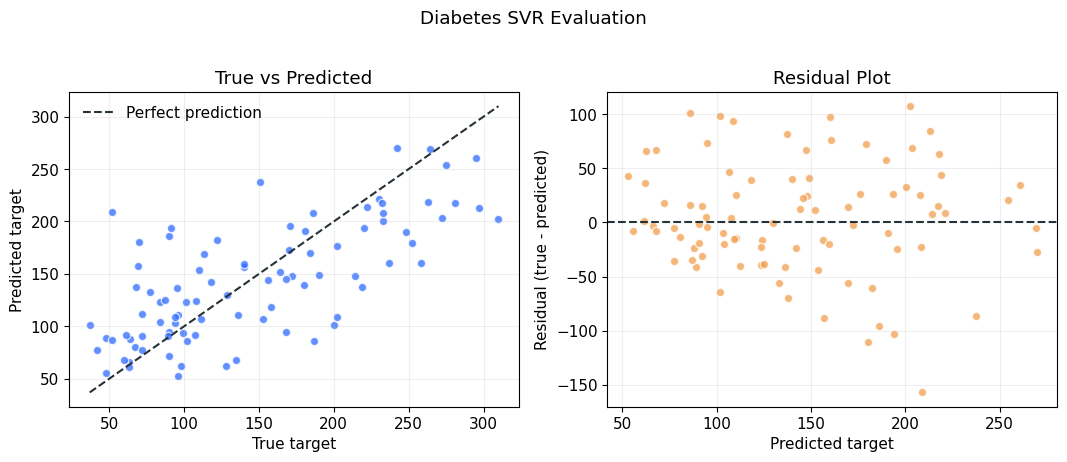

In [17]:
residuals = regression_y_test - regression_prediction
prediction_min = min(regression_y_test.min(), regression_prediction.min())
prediction_max = max(regression_y_test.max(), regression_prediction.max())

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.5))
axes[0].scatter(regression_y_test, regression_prediction, color=BLUE,
                alpha=0.75, edgecolor="white")
axes[0].plot([prediction_min, prediction_max], [prediction_min, prediction_max],
             "--", color=DARK, label="Perfect prediction")
axes[0].set(xlabel="True target", ylabel="Predicted target",
            title="True vs Predicted")
axes[0].legend(frameon=False)

axes[1].scatter(regression_prediction, residuals, color=ORANGE,
                alpha=0.75, edgecolor="white")
axes[1].axhline(0, linestyle="--", color=DARK)
axes[1].set(xlabel="Predicted target", ylabel="Residual (true - predicted)",
            title="Residual Plot")
fig.suptitle("Diabetes SVR Evaluation", y=1.02)
plt.tight_layout()
plt.show()

MAE 给出平均绝对偏差，RMSE 对大误差更敏感，$R^2$ 表示相对“恒预测均值”基线解释了多少变异。
真实值—预测值越接近对角线越好；残差应围绕 0 分布。该数据规模较小，结果用于教学，不应直接作为
医疗预测系统。

<a id="summary"></a>
## 4. 章节小结

**模型主线**：线性超平面 → 用几何间隔衡量鲁棒性 → 硬间隔最大化 → 松弛变量形成软间隔 →
Hinge Loss 可直接优化 → 对偶形式只含内积 → 核技巧得到非线性边界 → epsilon 不敏感损失扩展到 SVR。

**使用建议**：先标准化；线性核作为基线；非线性结构再尝试 RBF；用交叉验证共同选择 `C` 与
`gamma`；分类同时查看混淆矩阵和 ROC-AUC；回归同时查看 MAE、RMSE、$R^2$ 和残差。

本章推导按西瓜书与南瓜书的知识链整理；手写部分选择适合教学和直接运行的 Hinge Loss 次梯度实现；
sklearn 部分遵循官方接口与标准评估流程。书籍、GitHub 项目与官方文档已列在本章开头。

In [18]:
validation = {
    "manual_accuracy": float(manual_metrics["Accuracy"]),
    "manual_loss_start": float(manual_model.loss_history_[0]),
    "manual_loss_end": float(manual_model.loss_history_[-1]),
    "manual_support_vectors": int(manual_model.support_mask_.sum()),
    "basic_accuracy": float(basic_metrics["Accuracy"]),
    "basic_roc_auc": float(basic_metrics["ROC-AUC"]),
    "real_accuracy": float(real_metrics["Accuracy"]),
    "real_roc_auc": float(real_metrics["ROC-AUC"]),
    "svr_mae": float(svr_mae),
    "svr_rmse": float(svr_rmse),
    "svr_r2": float(svr_r2),
    "svr_support_vectors": int(len(svr_demo_support)),
    "image_count": 11,
}

assert np.all(np.isfinite(list(validation.values())))
assert validation["manual_loss_end"] < validation["manual_loss_start"]
assert validation["manual_accuracy"] >= 0.85
assert validation["basic_accuracy"] >= 0.85
assert validation["real_accuracy"] >= 0.88
assert validation["svr_r2"] >= 0.20
assert validation["svr_support_vectors"] >= 2

validation_rows = [
    ["手写模型 Loss", f'{validation["manual_loss_start"]:.3f} → {validation["manual_loss_end"]:.3f}', "通过"],
    ["手写模型 Accuracy", f'{validation["manual_accuracy"]:.3f}', "通过"],
    ["基础 RBF-SVC Accuracy", f'{validation["basic_accuracy"]:.3f}', "通过"],
    ["乳腺癌 SVC Accuracy", f'{validation["real_accuracy"]:.3f}', "通过"],
    ["糖尿病 SVR R²", f'{validation["svr_r2"]:.3f}', "通过"],
    ["已执行图表输出", f'{validation["image_count"]}', "通过"],
]
display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    validation_rows,
    hidden_comment="VALIDATION " + json.dumps(validation, ensure_ascii=False, sort_keys=True),
)

检查项,观测值,状态
手写模型 Loss,8.969 → 5.939,通过
手写模型 Accuracy,0.990,通过
基础 RBF-SVC Accuracy,0.958,通过
乳腺癌 SVC Accuracy,0.982,通过
糖尿病 SVR R²,0.500,通过
已执行图表输出,11,通过
